<a href="https://colab.research.google.com/github/gretadive/correlacion_actividad_solar_elnino/blob/main/03_limpieza_ssn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limpieza y preparación de datos SSN

Este notebook realiza la carga, validación, limpieza y preparación de los datos del Sunspot Number (SSN),

## Fuente de datos
- Variable: Sunspot Number (SSN)
- Fuente: World Data Center SILSO
- Archivo original: `ssn_original.txt`
- Ubicación en GitHub: `data/raw/SSN/`

In [11]:
from google.colab import userdata
import subprocess
import base64
import os

token = userdata.get("GITHUB_TOKEN")

usuario = "gretadive"
repo = "correlacion_actividad_solar_elnino"

credenciales = base64.b64encode(
    f"{usuario}:{token}".encode()
).decode()

ruta_repo = f"/content/{repo}"

resultado = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=Authorization: Basic {credenciales}",
        "clone",
        f"https://github.com/{usuario}/{repo}.git"
    ],
    capture_output=True,
    text=True
)

if resultado.returncode == 0:
    print("✅ Repositorio conectado correctamente")
else:
    print("❌ Error:")
    print(resultado.stderr)

✅ Repositorio conectado correctamente


In [14]:
%cd /content/correlacion_actividad_solar_elnino
!ls data/raw/SSN
!head -20 data/raw/SSN/ssn_original.txt

/content/correlacion_actividad_solar_elnino
README.md  ssn_original.txt
1749 01 1749.042   96.7  -1.0    -1  
1749 02 1749.123  104.3  -1.0    -1  
1749 03 1749.204  116.7  -1.0    -1  
1749 04 1749.288   92.8  -1.0    -1  
1749 05 1749.371  141.7  -1.0    -1  
1749 06 1749.455  139.2  -1.0    -1  
1749 07 1749.538  158.0  -1.0    -1  
1749 08 1749.623  110.5  -1.0    -1  
1749 09 1749.707  126.5  -1.0    -1  
1749 10 1749.790  125.8  -1.0    -1  
1749 11 1749.874  264.3  -1.0    -1  
1749 12 1749.958  142.0  -1.0    -1  
1750 01 1750.042  122.2  -1.0    -1  
1750 02 1750.123  126.5  -1.0    -1  
1750 03 1750.204  148.7  -1.0    -1  
1750 04 1750.288  147.2  -1.0    -1  
1750 05 1750.371  150.0  -1.0    -1  
1750 06 1750.455  166.7  -1.0    -1  
1750 07 1750.538  142.3  -1.0    -1  
1750 08 1750.623  171.7  -1.0    -1  


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "data/raw/SSN/ssn_original.txt"

df_ssn = pd.read_csv(
    ruta,
    sep=r"\s+",
    header=None,
    names=[
        "anio",
        "mes",
        "fecha_decimal",
        "SSN",
        "desviacion",
        "n_observaciones",
        "estado"
    ],
    engine="python"
)

df_ssn.head()


,anio,mes,fecha_decimal,SSN,desviacion,n_observaciones,estado
0,1749,1,1749.042,96.7,-1.0,-1,None
1,1749,2,1749.123,104.3,-1.0,-1,None
2,1749,3,1749.204,116.7,-1.0,-1,None
3,1749,4,1749.288,92.8,-1.0,-1,None
4,1749,5,1749.371,141.7,-1.0,-1,None


In [21]:
df_ssn.tail()

,anio,mes,fecha_decimal,SSN,desviacion,n_observaciones,estado
3327,2026,4,2026.286,79.3,11.4,1159,*
3328,2026,5,2026.371,101.5,14.8,1130,*
3329,2026,6,2026.453,94.4,15.6,1150,*
3330,2026,7,2026.538,78.1,11.2,1371,*
3331,2026,8,2026.623,76.0,12.3,1248,*


In [22]:
df_ssn["fecha"] = pd.to_datetime(
    dict(
        year=df_ssn["anio"],
        month=df_ssn["mes"],
        day=1
    )
)

df_ssn = df_ssn[
    [
        "fecha",
        "anio",
        "mes",
        "fecha_decimal",
        "SSN",
        "desviacion",
        "n_observaciones",
        "estado"
    ]
]

df_ssn.head()

,fecha,anio,mes,fecha_decimal,SSN,desviacion,n_observaciones,estado
0,1749-01-01,1749,1,1749.042,96.7,-1.0,-1,None
1,1749-02-01,1749,2,1749.123,104.3,-1.0,-1,None
2,1749-03-01,1749,3,1749.204,116.7,-1.0,-1,None
3,1749-04-01,1749,4,1749.288,92.8,-1.0,-1,None
4,1749-05-01,1749,5,1749.371,141.7,-1.0,-1,None


In [23]:
df_ssn["desviacion"] = df_ssn["desviacion"].replace(-1.0, np.nan)
df_ssn["n_observaciones"] = df_ssn["n_observaciones"].replace(-1, np.nan)

In [24]:
print("Total de registros:", len(df_ssn))
print("Periodo:", df_ssn["fecha"].min(), "a", df_ssn["fecha"].max())
print("Fechas duplicadas:", df_ssn["fecha"].duplicated().sum())

print("\nValores faltantes:")
print(df_ssn.isnull().sum())

print("\nEstadísticas del SSN:")
print(df_ssn["SSN"].describe())

Total de registros: 3332
Periodo: 1749-01-01 00:00:00 a 2026-08-01 00:00:00
Fechas duplicadas: 0

Valores faltantes:
fecha                 0
anio                  0
mes                   0
fecha_decimal         0
SSN                   0
desviacion          828
n_observaciones     828
estado             3327
dtype: int64

Estadísticas del SSN:
count    3332.000000
mean       82.202131
std        67.566396
min         0.000000
25%        24.400000
50%        68.750000
75%       123.000000
max       398.200000
Name: SSN, dtype: float64


In [25]:
df_ssn = df_ssn.sort_values("fecha").reset_index(drop=True)

fechas_esperadas = pd.date_range(
    start=df_ssn["fecha"].min(),
    end=df_ssn["fecha"].max(),
    freq="MS"
)

fechas_faltantes = fechas_esperadas.difference(df_ssn["fecha"])

print("Total de registros:", len(df_ssn))
print("Meses faltantes:", len(fechas_faltantes))
print("Fechas duplicadas:", df_ssn["fecha"].duplicated().sum())
print("Periodo:", df_ssn["fecha"].min(), "a", df_ssn["fecha"].max())

Total de registros: 3332
Meses faltantes: 0
Fechas duplicadas: 0
Periodo: 1749-01-01 00:00:00 a 2026-08-01 00:00:00


In [26]:
df_ssn.to_csv(
    "data/processed/ssn_procesado.csv",
    index=False,
    encoding="utf-8"
)

print("✅ SSN procesado guardado correctamente")

✅ SSN procesado guardado correctamente


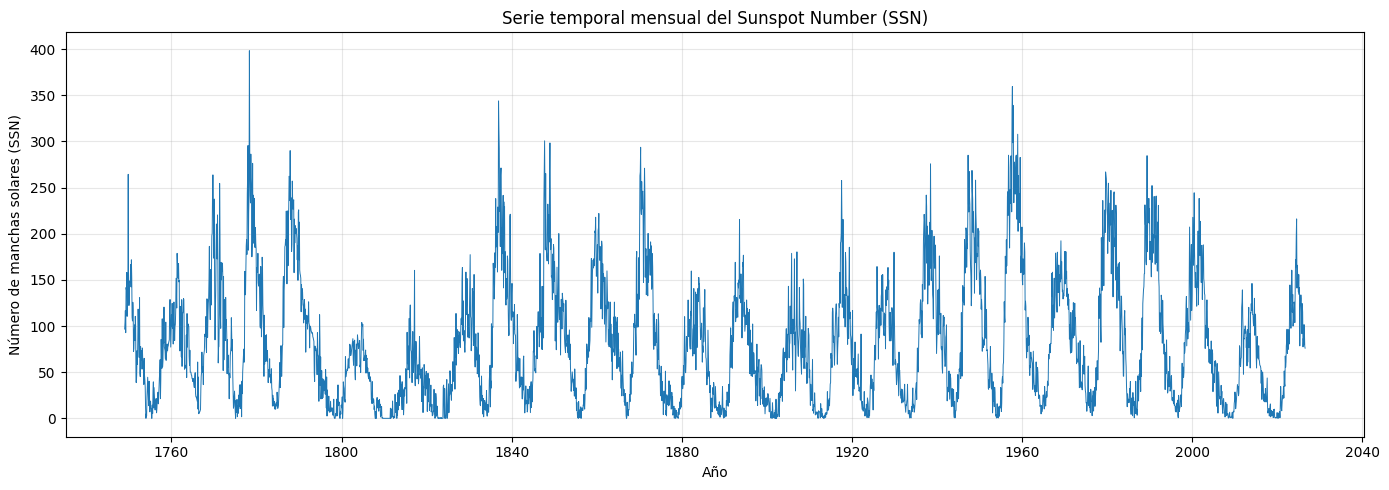

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    df_ssn["fecha"],
    df_ssn["SSN"],
    linewidth=0.7
)

plt.xlabel("Año")
plt.ylabel("Número de manchas solares (SSN)")
plt.title("Serie temporal mensual del Sunspot Number (SSN)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/serie_temporal_ssn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
!git config user.name "gretadive"
!git config user.email "gretadive@users.noreply.github.com"

!git add data/processed/ssn_procesado.csv
!git add figures/serie_temporal_ssn.png

!git commit -m "Procesar datos SSN y agregar serie temporal"

[main f76cb45] Procesar datos SSN y agregar serie temporal
 2 files changed, 3333 insertions(+)
 create mode 100644 data/processed/ssn_procesado.csv
 create mode 100644 figures/serie_temporal_ssn.png


In [30]:
from google.colab import userdata
import subprocess
import base64

token = userdata.get("GITHUB_TOKEN")
usuario = "gretadive"

credenciales = base64.b64encode(
    f"{usuario}:{token}".encode()
).decode()

resultado = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=Authorization: Basic {credenciales}",
        "push",
        "origin",
        "main"
    ],
    capture_output=True,
    text=True
)

if resultado.returncode == 0:
    print("✅ SSN enviado correctamente a GitHub")
else:
    print("❌ Error:")
    print(resultado.stderr)

✅ SSN enviado correctamente a GitHub
